In [ ]:
import pandas as pd
boa_df = pd.read_csv('../data/processed/bank_of_abyssinia_cleaned_reviews.csv')
boa_df.head()

In [ ]:
# Number of rows and columns
print("Shape:", boa_df.shape)

# Column types and non-null counts
print("\nInfo:")
print(boa_df.info())

# Check for missing values
print("\nMissing values:")
print(boa_df.isnull().sum())


In [5]:
# Check for duplicates
print("Duplicates:", boa_df.duplicated().sum())

# Drop duplicates (if any)
boa_df.drop_duplicates(inplace=True)

# Quick summary of ratings
print("\nRatings summary:")
print(boa_df['rating'].describe())


Duplicates: 0

Ratings summary:
count    491.000000
mean       2.276986
std        1.714482
min        1.000000
25%        1.000000
50%        1.000000
75%        4.000000
max        5.000000
Name: rating, dtype: float64


C:\Users\PC\AppData\Local\Temp\ipykernel_15404\2887084468.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=boa_df, palette='viridis')


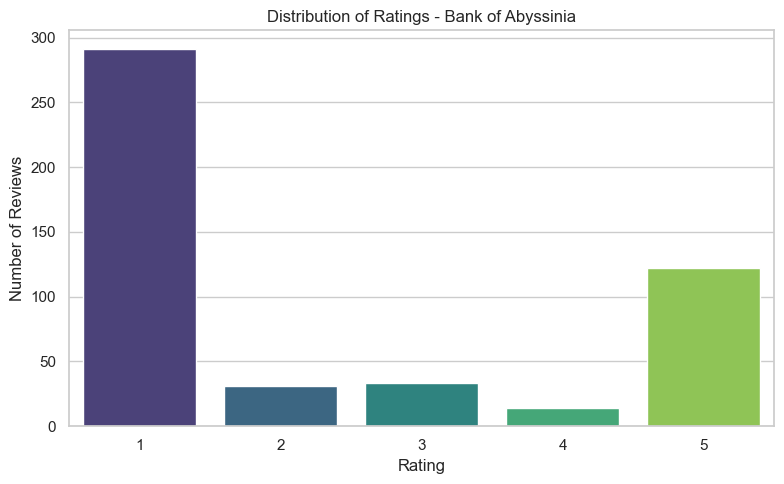

In [7]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Plot histogram
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=boa_df, palette='viridis')
plt.title('Distribution of Ratings - Bank of Abyssinia')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()


Average Rating Over Time

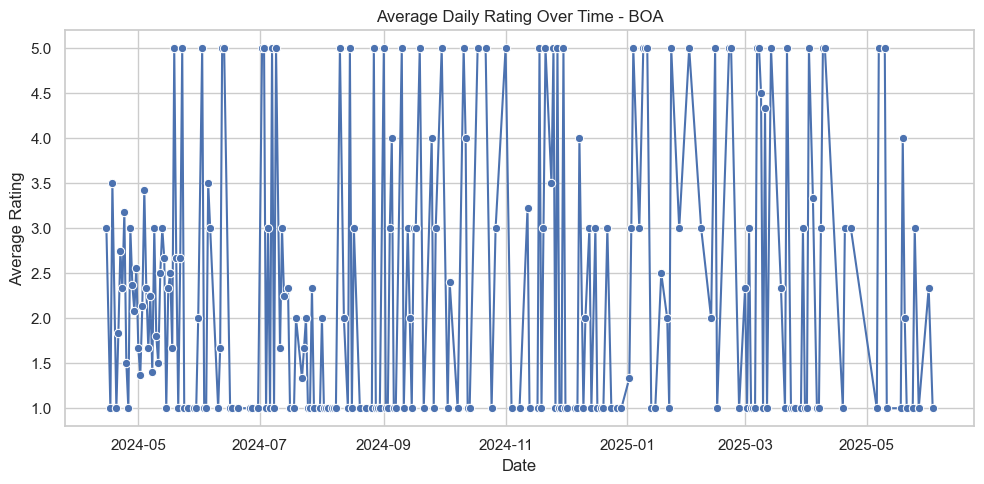

In [8]:
# Convert date column to datetime if not already
boa_df['date'] = pd.to_datetime(boa_df['date'])

# Group by date and compute mean rating
daily_avg = boa_df.groupby('date')['rating'].mean().reset_index()

# Plot the trend
plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_avg, x='date', y='rating', marker='o')
plt.title('Average Daily Rating Over Time - BOA')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()


Plot daily Review Counts: This helps reveal how many users left reviews per day (regardless of rating), highlighting spikes or dips in engagement.

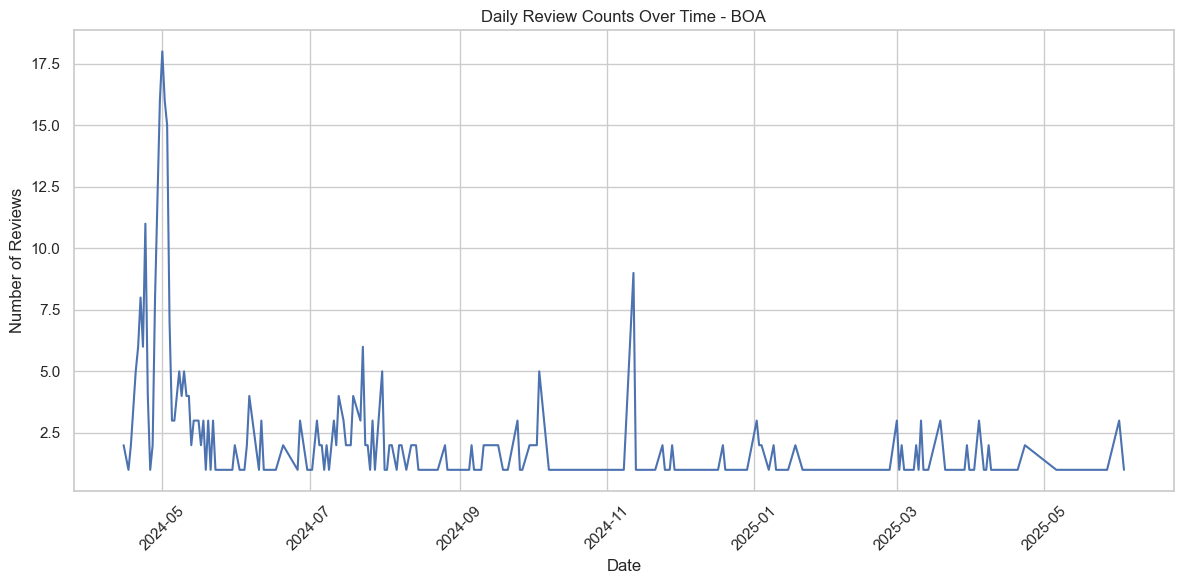

In [9]:
# Group by date and count reviews
daily_review_counts = boa_df.groupby('date').size()

# Plot daily review counts
plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_review_counts.index, y=daily_review_counts.values)
plt.title('Daily Review Counts Over Time - BOA')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Analyze 1-Star Reviews: isolate 1-star reviews and see what users are complaining about.

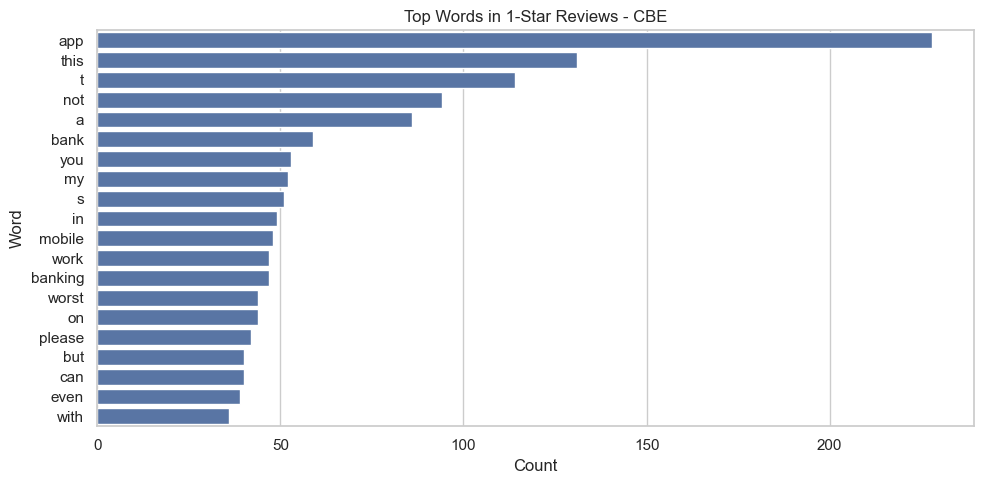

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# If your CSV file is loaded like this
df = pd.read_csv('../data/processed/bank_of_abyssinia_cleaned_reviews.csv') # or however you loaded your data
df['date'] = pd.to_datetime(df['date'])  # ensure date column is datetime format
# Filter 1-star reviews
one_star_reviews = df[df['rating'] == 1]

# Check most common words (basic version)
from collections import Counter
import re

# Combine all reviews into one string
all_text = " ".join(one_star_reviews['review'].dropna().astype(str))

# Tokenize and clean
words = re.findall(r'\b\w+\b', all_text.lower())
filtered_words = [word for word in words if word not in ['the', 'is', 'and', 'to', 'i', 'it', 'was', 'for', 'of']]  # stop words

# Count top words
word_freq = Counter(filtered_words).most_common(20)

# Convert to DataFrame and plot
word_df = pd.DataFrame(word_freq, columns=['word', 'count'])

plt.figure(figsize=(10, 5))
sns.barplot(x='count', y='word', data=word_df)
plt.title('Top Words in 1-Star Reviews - CBE')
plt.xlabel('Count')
plt.ylabel('Word')
plt.tight_layout()
plt.show()


In [11]:
df.to_csv("clean_boa_reviews.csv", index=False)
